$$\frac{\partial h}{\partial t}=U+K_d\Bigl(\frac{\partial^2h}{\partial x^2}+\frac{\partial^2h}{\partial y^2}\Bigr)$$
$$h(t=0)=h_0(x,y)$$
$$h(x=0)=h(x=L_x),\ h(y=0)=0,\ h(y=L_y)=0$$

In [6]:
import numpy as np
import matplotlib.pyplot as plt


In [7]:
Lx = 2000
Ly = 1000
nx = 201
ny = 101
dx = Lx/(nx - 1)
dy = Ly/(ny - 1)
Kd = 1e-2
U = 1e-4
dt = 1000
Courant = [dt*Kd/dx**2,dt*Kd/dy**2]
print(Courant)
nstep = 10000

[0.1, 0.1]


$$h_{i,j}=h_{i,j}+U\Delta t+K_d\Delta t\Bigl(\frac{h_{i+1,j}-2h_{i,j}+h_{i-1,j}}{\Delta x^2}+\frac{h_{i,j+1}-2h_{i,j}+h_{i,j-1}}{\Delta y^2}\Bigr)$$

In [12]:
dum = np.linspace(0,1,11)
print(dum)
print(np.roll(dum,1,axis=0))
print(np.roll(dum,-1,axis=0))

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
[1.  0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  0. ]


In [13]:
h = np.zeros((ny,nx))

for step in range(nstep):
    h[1:-1,:] = h[1:-1,:] + U*dt # to impose the uplift
    h[1:-1,:] = h[1:-1,:] + Kd*dt*(
                                  (np.roll(h[1:-1,:],1,axis=1)-2*h[1:-1,:]+np.roll(h[1:-1,:],-1,axis=1))/dx**2 
                                + (h[2:,:]-2*h[1:-1,:]+h[:-2,:])/dy**2
                                  )# to solve the 2D diffusion equation

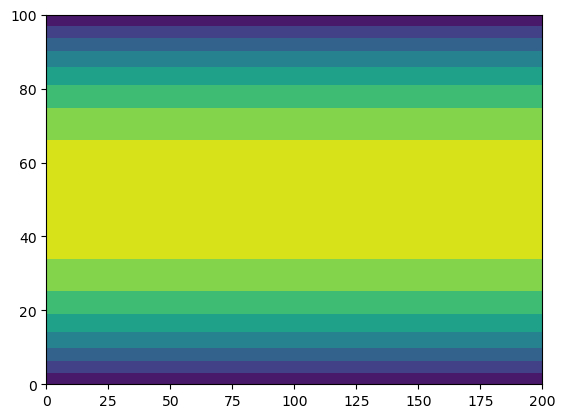

In [14]:
plt.contourf(h)

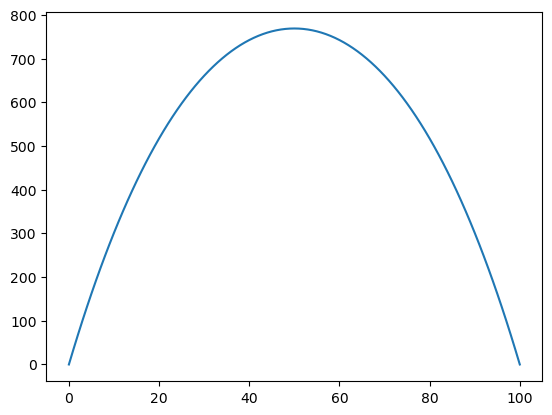

In [16]:
plt.plot(h[:,101])